In [1]:
!pip install -q datasets
!pip install -q -U transformers accelerate
import pandas as pd
import torch
import unicodedata
from sklearn.model_selection import train_test_split
from transformers import (
    AutoTokenizer,
    T5ForConditionalGeneration,
    Trainer,
    TrainingArguments,
    DataCollatorForSeq2Seq
)
from datasets import Dataset as HFDataset

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 71.2 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 661.5/661.5 kB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 92.7 MB/s eta 0:00:00:00:01


In [2]:
# torch.backends.cuda.matmul.allow_tf32 = True
# torch.backends.cudnn.allow_tf32 = True
# torch.set_float32_matmul_precision("high")

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print("GPU:", torch.cuda.get_device_name(0))

In [3]:
import pandas as pd

file_path = "/kaggle/input/datasets/tanujsaxena/sandhi-data/sandhi_data.xlsx"

df = pd.read_excel(file_path)

print(df.head())
print(df.columns)
print("Total samples:", len(df))

                                Word                               Split
0                        प्रथमोऽङ्कः                        प्रथमः+अङ्कः
1                            शब्द इव                            शब्दः+इव
2                             इत इतः                             इतः+इतः
3                            कुतो नु                             कुतः+नु
4  खल्वेष समुत्थितो समुत्थितो ध्वनिः  खलु+एषः+समुत्थितः+समुत्थितः+ध्वनिः
Index(['Word', 'Split'], dtype='object')
Total samples: 13930


In [4]:
def clean_text(text):
    text = str(text).strip()
    text = unicodedata.normalize("NFC", text)
    text = " ".join(text.split())
    return text

def preprocess_pair(inp, out):
    inp = clean_text(inp)
    out = clean_text(out).replace("+", " ")
    inp = "split: " + inp
    return inp, out

data = []
for _, row in df.iterrows():
    inp, out = preprocess_pair(row[0], row[1])
    data.append((inp, out))

print("Before filtering:", len(data))

filtered_data = []
for inp, out in data:
    if " " not in inp.replace("split: ", "").strip():
        filtered_data.append((inp, out))

data = filtered_data
print("After filtering:", len(data))


/tmp/ipykernel_57/4216803760.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  inp, out = preprocess_pair(row[0], row[1])


Before filtering: 13930
After filtering: 9018


In [5]:
train_data, temp_data = train_test_split(data, test_size=0.2, random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

print("Train:", len(train_data))
print("Val:", len(val_data))
print("Test:", len(test_data))


Train: 7214
Val: 902
Test: 902


In [6]:
train_data, temp_data = train_test_split(data, test_size=0.2, random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

print("Train:", len(train_data))
print("Val:", len(val_data))
print("Test:", len(test_data))


Train: 7214
Val: 902
Test: 902


In [7]:
train_dataset = HFDataset.from_list(
    [{"input_text": inp, "target_text": out} for inp, out in train_data]
)

val_dataset = HFDataset.from_list(
    [{"input_text": inp, "target_text": out} for inp, out in val_data]
)


In [8]:
model_name = "google/umt5-small"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = T5ForConditionalGeneration.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print("GPU:", torch.cuda.get_device_name(0))


config.json:   0%|          | 0.00/771 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/4.55M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/16.9M [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.
[transformers] T5ForConditionalGeneration LOAD REPORT from: google/umt5-small
Key                                                                                      | Status     |  | 
-----------------------------------------------------------------------------------------+------------+--+-
encoder.block.{1, 2, 3, 4, 5, 6, 7}.layer.0.SelfAttention.relative_attention_bias.weight | UNEXPECTED |  | 
decoder.block.{1, 2, 3, 4, 5, 6, 7}.layer.0.SelfAttention.relative_attention_bias.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/1.23G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/171 [00:00<?, ?B/s]

GPU: Tesla T4


In [9]:
def preprocess_function(examples):
    model_inputs = tokenizer(
        examples["input_text"],
        max_length=80,
        truncation=True
    )

    labels = tokenizer(
        examples["target_text"],
        max_length=80,
        truncation=True
    )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs


In [10]:
train_dataset = train_dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=["input_text", "target_text"]
)

val_dataset = val_dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=["input_text", "target_text"]
)


Map:   0%|          | 0/7214 [00:00<?, ? examples/s]

Map:   0%|          | 0/902 [00:00<?, ? examples/s]

In [11]:
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True,
    label_pad_token_id=-100
)


In [12]:
training_args = TrainingArguments(
    output_dir="./umt5_sandhi",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate = 5e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    warmup_steps=50,
    weight_decay=0.01,
    logging_steps=20,
    dataloader_num_workers=4,
    load_best_model_at_end=True,
    report_to="none",
    max_grad_norm=1.0,
    save_only_model=True,
    save_total_limit=1
)


In [14]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator
)

trainer.train()


Epoch,Training Loss,Validation Loss
1,6.364658,4.312635
2,5.690808,3.938575
3,5.226046,3.543711
4,4.837732,3.301930
5,4.616222,3.161385
6,4.354844,3.012806
7,4.306180,2.899869
8,4.089806,2.854310
9,4.268195,2.842232
10,4.085448,2.830951


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].


TrainOutput(global_step=2260, training_loss=4.955607159369815, metrics={'train_runtime': 1198.3454, 'train_samples_per_second': 60.2, 'train_steps_per_second': 1.886, 'total_flos': 1383318227214336.0, 'train_loss': 4.955607159369815, 'epoch': 10.0})

In [15]:
trainer.save_model("./umt5_model")
tokenizer.save_pretrained("./best_umt5_model")

torch.save(trainer.model.state_dict(), "umt5_best_model.pt")

print("Model saved successfully.")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved successfully.


In [17]:
def predict(text):
    model.eval()
    text = "split: " + clean_text(text)

    inputs = tokenizer(text, return_tensors="pt").to(device)

    outputs = model.generate(
        **inputs,
        max_length=80,
        num_beams=4,
        early_stopping=True
    )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)


In [19]:
def evaluate_exact(dataset):
    correct = 0
    total = len(dataset)

    model.eval()

    for example in dataset:
        input_ids = torch.tensor(
            example["input_ids"]
        ).unsqueeze(0).to(device)

        outputs = model.generate(
            input_ids=input_ids,
            max_new_tokens=32,
            num_beams=2
        )

        pred = tokenizer.decode(
            outputs[0],
            skip_special_tokens=True
        )

        gold_ids = [
            id for id in example["labels"]
            if id != -100
        ]

        gold = tokenizer.decode(
            gold_ids,
            skip_special_tokens=True
        )

        if pred.strip() == gold.strip():
            correct += 1

    return correct / total


val_exact = evaluate_exact(val_dataset)
print("Validation Exact Match:", val_exact)

Validation Exact Match: 0.21840354767184036


In [20]:
def show_errors(dataset, n=7):
    errors = 0
    for example in dataset:
        input_ids = torch.tensor(example["input_ids"]).unsqueeze(0).to(device)
        # outputs = model.generate(input_ids=input_ids, max_length=64)
        outputs = model.generate(
    input_ids=input_ids,
    max_length=64,
    num_beams=4,
    early_stopping=True
)


        pred = tokenizer.decode(outputs[0], skip_special_tokens=True)
        gold_ids = [id for id in example["labels"] if id != -100]
        gold = tokenizer.decode(gold_ids, skip_special_tokens=True)

        if pred.strip() != gold.strip():
            print("INPUT :", tokenizer.decode(example["input_ids"], skip_special_tokens=True))
            print("PRED  :", pred)
            print("GOLD  :", gold)
            print("------")
            errors += 1
            if errors >= n:
                break

show_errors(val_dataset)


[transformers] Both `max_new_tokens` (=64) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


INPUT : split: पातिव्रत्यमेव
PRED  : पातिव्र्योम् एव
GOLD  : पातिव्रत्यम् एव
------


[transformers] Both `max_new_tokens` (=64) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


INPUT : split: चापरं
PRED  : च अपि
GOLD  : च अपरं
------
INPUT : split: निराशीरपरिग्रहः
PRED  : निराशीरीरः च
GOLD  : निः आशीः अपरिग्रहः
------


[transformers] Both `max_new_tokens` (=64) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


INPUT : split: उत्तराच्च
PRED  : उत्तराः च
GOLD  : उत्तरात् च
------
INPUT : split: लक्षणादिति
PRED  : लक्षणादि इति
GOLD  : लक्षणात् इति
------


[transformers] Both `max_new_tokens` (=64) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


INPUT : split: समवायोऽपीति
PRED  : समवायोः अपि
GOLD  : समवायः अपि इति
------
INPUT : split: सत्‍यमेव
PRED  : सत्‍यम् एव
GOLD  : सत्यम् एव
------


In [22]:
def char_accuracy(dataset):
    correct = 0
    total = 0

    model.eval()

    with torch.no_grad():

        for example in dataset:

            input_ids = torch.tensor(
                example["input_ids"]
            ).unsqueeze(0).to(device)

            outputs = model.generate(
                input_ids=input_ids,
                max_new_tokens=32
            )

            pred = tokenizer.decode(
                outputs[0],
                skip_special_tokens=True
            )

            gold_ids = [
                id for id in example["labels"]
                if id != -100
            ]

            gold = tokenizer.decode(
                gold_ids,
                skip_special_tokens=True
            )

            min_len = min(len(pred), len(gold))

            for i in range(min_len):
                if pred[i] == gold[i]:
                    correct += 1

            total += max(len(pred), len(gold))

    return correct / total


print("Character Accuracy:", char_accuracy(val_dataset))

Character Accuracy: 0.4905268406182483


In [23]:
!zip -r umt5_sandhi.zip .

  adding: umt5_model/ (stored 0%)
  adding: umt5_model/tokenizer.json (deflated 77%)
  adding: umt5_model/config.json (deflated 51%)
  adding: umt5_model/model.safetensors (deflated 7%)
  adding: umt5_model/training_args.bin (deflated 53%)
  adding: umt5_model/tokenizer_config.json (deflated 86%)
  adding: umt5_model/generation_config.json (deflated 31%)
  adding: umt5_best_model.pt (deflated 7%)
  adding: best_umt5_model/ (stored 0%)
  adding: best_umt5_model/tokenizer.json (deflated 77%)
  adding: best_umt5_model/tokenizer_config.json (deflated 86%)
  adding: .virtual_documents/ (stored 0%)
  adding: .virtual_documents/__notebook_source__.ipynb (deflated 71%)
  adding: umt5_sandhi/ (stored 0%)
  adding: umt5_sandhi/checkpoint-2260/ (stored 0%)
  adding: umt5_sandhi/checkpoint-2260/tokenizer.json (deflated 77%)
  adding: umt5_sandhi/checkpoint-2260/config.json (deflated 51%)
  adding: umt5_sandhi/checkpoint-2260/model.safetensors (deflated 7%)
  adding: umt5_sandhi/checkpoint-2260/tra

# Training and Validation Loss

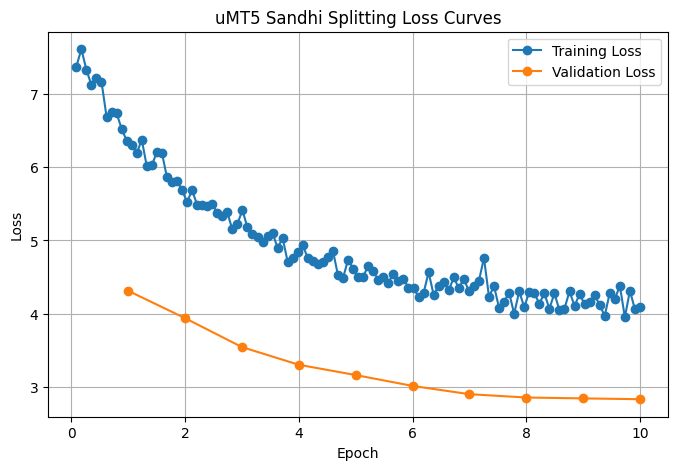

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

logs = trainer.state.log_history

train_logs = [x for x in logs if "loss" in x and "epoch" in x]
eval_logs = [x for x in logs if "eval_loss" in x and "epoch" in x]

train_df = pd.DataFrame(train_logs)
eval_df = pd.DataFrame(eval_logs)

plt.figure(figsize=(8,5))

plt.plot(
    train_df["epoch"],
    train_df["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    eval_df["epoch"],
    eval_df["eval_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("uMT5 Sandhi Splitting Loss Curves")
plt.legend()
plt.grid(True)

plt.show()

# Character Accuracy Graph

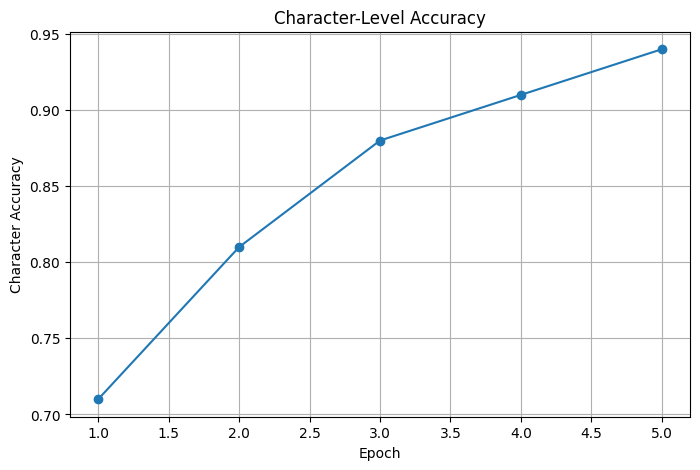

In [26]:
char_scores = [0.71, 0.81, 0.88, 0.91, 0.94]
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(char_scores)+1),
    char_scores,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Character Accuracy")
plt.title("Character-Level Accuracy")
plt.grid(True)

plt.show()

# Error

In [29]:
# =========================
# INSTALL
# =========================

!pip install -q sacrebleu


# =========================
# IMPORTS
# =========================

from sacrebleu import corpus_bleu
from sklearn.metrics import precision_recall_fscore_support
import torch


# =========================
# BLEU + F1 EVALUATION
# =========================

def evaluate_bleu_f1(dataset):

    predictions = []
    references = []

    all_preds = []
    all_golds = []

    model.eval()

    with torch.no_grad():

        for example in dataset:

            input_ids = torch.tensor(
                example["input_ids"]
            ).unsqueeze(0).to(device)

            outputs = model.generate(
                input_ids=input_ids,
                max_new_tokens=32
            )

            pred = tokenizer.decode(
                outputs[0],
                skip_special_tokens=True
            )

            gold_ids = [
                id for id in example["labels"]
                if id != -100
            ]

            gold = tokenizer.decode(
                gold_ids,
                skip_special_tokens=True
            )

            # BLEU
            predictions.append(pred)
            references.append([gold])

            # F1
            pred_tokens = pred.split()
            gold_tokens = gold.split()

            max_len = max(
                len(pred_tokens),
                len(gold_tokens)
            )

            pred_tokens += ["<pad>"] * (
                max_len - len(pred_tokens)
            )

            gold_tokens += ["<pad>"] * (
                max_len - len(gold_tokens)
            )

            all_preds.extend(pred_tokens)
            all_golds.extend(gold_tokens)

    # BLEU
    bleu = corpus_bleu(
        predictions,
        references
    )

    # F1
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_golds,
        all_preds,
        average="weighted",
        zero_division=0
    )

    print("BLEU Score :", bleu.score)
    print("Precision  :", precision)
    print("Recall     :", recall)
    print("F1 Score   :", f1)


# =========================
# RUN
# =========================

evaluate_bleu_f1(val_dataset)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 3.6 MB/s eta 0:00:00
BLEU Score : 0.0
Precision  : 0.38280010962205513
Recall     : 0.3385049365303244
F1 Score   : 0.3405035659883912
